# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [2]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [3]:
print(f'\nSlope (coefficient):  {model.coef_[0]:.2f}')
print(f'Intercept:            {model.intercept_:.2f}')


Slope (coefficient):  4.10
Intercept:            47.68


In [4]:
y_pred = model.predict(X_test)
print('Actual scores:   ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:    [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [5]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


The R squared score of 0.998 means that approximately 99.8% of the variation in the test exam scores is perfectly explained by the number of hours studied. This tells us that the linear regression model has an exceptionally high and strong fit to this dataset.

C:\Users\Dania Kabakibi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


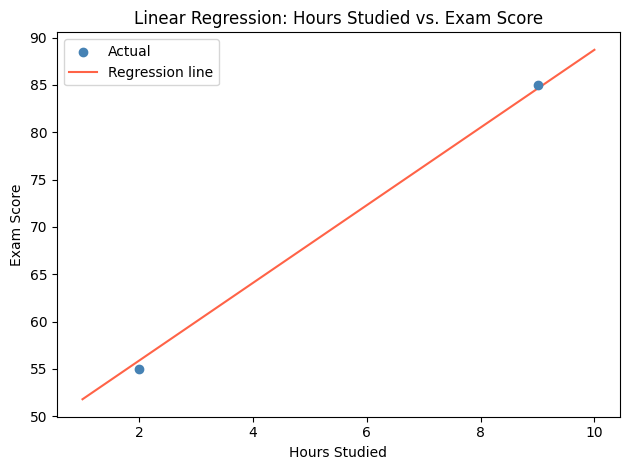

In [6]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

Looking at the scatter plot, the actual test data points follow the regression line extremely closely. This visual pattern aligns perfectly with our high R squared score of 0.998, indicating that the linear regression model accurately captures the nearly perfect positive linear relationship between hours studied and exam scores.

## Lab 2
### Building your own model

In [7]:
ad_data = { 
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500,
                     6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000], 
'monthly_revenue':  [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800, 12400, 13100,
                     14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100, 23800] 
}

df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [8]:
x2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print("x2 shape: ", x2.shape)
print("y2 shape: ", y2.shape)

x2 shape:  (20, 1)
y2 shape:  (20,)


In [9]:
x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2, test_size=.3, random_state=10
)

In [10]:
model2 = LinearRegression()
model2.fit(x2_train, y2_train)

print('Model trained successfully.')

Model trained successfully.


In [11]:
print(f'The slope: {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')
# For each additional $1.00 spent on monthly ads,
# the predicted monthly revenue increases by approximately $2.01

The slope: 2.00
Intercept: 3386.09


### Making predictions and evaluating the model

In [12]:
y2_pred = model2.predict(x2_test)

print('Actual revenue: ', list(y2_test))
print('Predicted revenue: ', list(y2_pred.round(2)))

act_pre = {
    'Actual': list(y2_test),
    'Predicted': list(y2_pred.round(2))
}
df_pre = pd.DataFrame(act_pre)
df_pre

Actual revenue:  [11800, 14200, 9200, 10500, 7400, 22100]
Predicted revenue:  [np.float64(11375.5), np.float64(14371.52), np.float64(9378.15), np.float64(10376.82), np.float64(7380.79), np.float64(22360.93)]


,Actual,Predicted
0,11800,11375.50
1,14200,14371.52
2,9200,9378.15
3,10500,10376.82
4,7400,7380.79
5,22100,22360.93


In [13]:
r2_squared = model2.score(x2_test, y2_test)
print(f'R² score: {r2_squared:.3f}')

R² score: 0.998


Yes, the model appears to be an exceptionally good fit for the data.
The R squared score is approximately 0.998. This means that 99.8% of the variation in monthly revenue can be perfectly explained by the amount of money spent on monthly advertisements. The remaining 0.2% is random variance or external factors.

### Visualizing the results

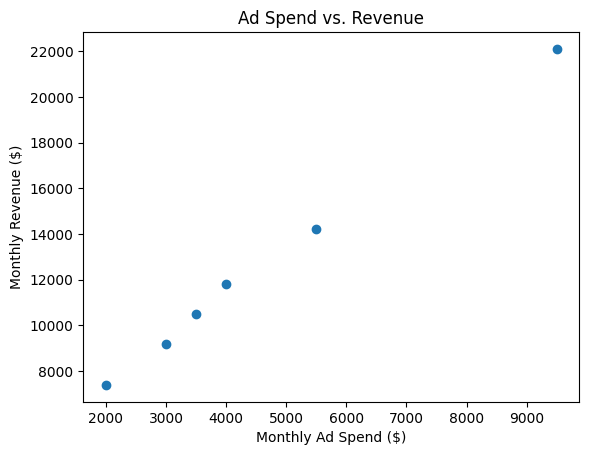

In [14]:
plt.scatter(x2_test, y2_test)
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.show()

C:\Users\Dania Kabakibi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Dania Kabakibi\AppData\Local\Temp\ipykernel_21956\586949280.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


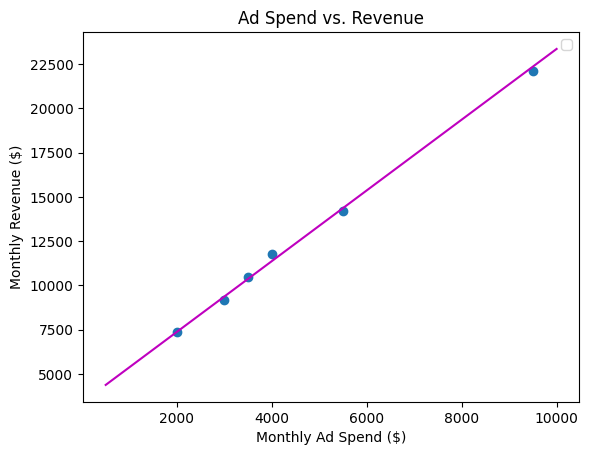

In [15]:
plt.scatter(x2_test, y2_test)
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

x2_range = np.linspace(
    x2['monthly_ad_spend'].min(),
    x2['monthly_ad_spend'].max(),
    100
    ).reshape(-1, 1)
y2_line = model2.predict(x2_range)

plt.plot(x2_range, y2_line, color='m')
plt.legend()
plt.show()

The regression line fits the data points remarkably well. The points form a tight, and the line cuts directly through the exact center of all coordinates. This perfectly matches what our R squared score told us. A score of 0.998 mathematically states that the data points line up almost perfectly with our linear trend line, which is exactly what we see in the graph.

### When changing the parameters to test_size=0.3 and random_state=10:
The calculated slope and intercept shifted slightly. This happens because changing the random state and test size selects a different mix of data rows to train the model on.